# 03 · 작은 채널 공간에서의 global solution

## 정확히 무엇에 대한 전역해인가

새로 만든 $v\ge0$와 $T(1),\ldots,T(n)>0$, $n=16$에 대해 $\mathcal M=\{0,1\}^n$ 전체를 계산한다. $2^{16}=65536$개의 점을 사용하며 실제 SSD global optimum이라고 부르지 않는다.

$$I(M)=v^TM,\quad L(M)=\sum_{C\in\mathcal R(M)}T(|C|),\quad
I^*(B)=\max_{M:L(M)\le B}I(M),\quad L^*(Q)=\min_{M:I(M)\ge Q}L(M).$$

cost는 smooth plateau 모형과 비선형 양수 table을 각각 새로 만든다. importance는 flat·smooth·spiky 입력과 여러 seed를 사용한다. oracle 계산은 각 mask의 연속 1 길이를 열 단위로 누적하므로 selector의 recurrence를 재사용하지 않는다.

## 실행 준비

결과는 `runs/03_global_oracle/`에 저장합니다. 이 셀을 다시 실행하면 해당 폴더의 이전 결과를 지우고 새로 만듭니다.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if (ROOT / "conclusion/python").is_dir():
    ROOT = ROOT / "conclusion/python"
sys.path.insert(0, str(ROOT))
import core as C
from reporting import begin, figure, finish
SEED = 20260926
RUN = begin(ROOT, "03_global_oracle", SEED)

**결과:** `runs/03_global_oracle/` · seed `20260926`

## 비교 방법과 평가량

Top-$R$, Algorithm 1의 다중 길이 greedy, shifted saturation tiles, 실험 01의 비율 정확해를 비교한다. 앞의 세 방법은 같은 nominal $R$을 받으며 실제 $|M|$도 저장한다. 비율 정확해는 $|M|\le R$이므로 이와 구분한다. 모든 방법은 **선택 후 최대 run을 합친 같은 $L$**로 평가한다.

$$g_I(M)=\frac{I^*(L(M))-I(M)}{\max(I^*(L(M)),10^{-12})},\qquad
g_L(M)=\frac{L(M)-L^*(I(M))}{\max(L^*(I(M)),10^{-12})}.$$

두 regret은 모두 $\ge0$이며 서로 다른 제약 문제를 측정한다. Ratio regret은 $1-(I/L)/(I/L)^*$로 별도 계산한다. 같은 $R$에서 더 많은 importance를 보존했지만 latency도 증가한 방법을 단일 숫자로 “우월”하다고 하지 않는다.

Algorithm 1은 논문의 row-unit 의사코드를 직접 짧게 구현한다. 기본 비교는 최소 길이 1, step 1, stride cap 1로 둔다. 이는 후보가 촘촘한 baseline이며 논문의 KiB 기본값이나 GPU 정렬 runtime을 재현한 설정은 아니다. `check_algorithms.py`는 같은 후보 범위에서 로컬 reference 구현과 선택 mask가 일치하는지 별도 검증한다.

## 실험 설계

첫 입력에서는 모든 점, Pareto 계단, 각 방법의 점, mask heatmap을 함께 출력한다. 이후 3종 importance × 4 seed × 2 cost 모형에서 $R\in\{4,8,12\}$를 평가한다. 분포별 regret을 보여주어 한 favorable 입력만 고르지 않는다. 정확해를 찾기 위한 $2^n$ 탐색은 검증 도구이며 큰 모델용 제안 알고리즘이 아니다.

In [2]:
n, s = 16, 4
records, illustration = [], None
for kind in ["flat", "smooth", "spiky"]:
    for seed in range(4):
        v = C.workload(n, SEED + seed, kind)
        for curve in ["plateau", "irregular"]:
            cost = C.two_line(n, s)
            if curve == "irregular":
                cost[1:] *= np.random.default_rng(seed + 10).uniform(.8, 1.2, n)
            masks, imp, delay = C.exhaustive(v, cost)
            for r in [4, 8, 12]:
                methods = {"Top-R": C.topk(v, r), "Paper": C.paper(v, r, cost, s),
                           "Saturation": C.saturation(v, r, cost, s), "Ratio exact": C.ratio_opt(v, r, cost)}
                for method, mask in methods.items():
                    i, l = float(v[mask].sum()), C.latency(mask, cost)
                    best_i = imp[delay <= l + 1e-12].max()
                    best_l = delay[imp >= i - 1e-12].min()
                    allowed = (masks.sum(1) > 0) & (masks.sum(1) <= r)
                    best_ratio = (imp[allowed] / delay[allowed]).max()
                    records.append(dict(kind=kind, seed=seed, curve=curve, R=r, method=method,
                                        importance=i, latency=l, selected=int(mask.sum()),
                                        importance_gap=(best_i - i) / best_i,
                                        latency_gap=(l - best_l) / best_l,
                                        ratio_gap=1 - (i / l) / best_ratio))
                if (kind, seed, curve, r) == ("spiky", 0, "plateau", 8):
                    illustration = v.copy(), cost.copy(), imp, delay, methods
frame = pd.DataFrame(records)
assert frame[["importance_gap", "latency_gap", "ratio_gap"]].min().min() > -1e-10
frame.to_csv(RUN / "oracle_gaps.csv", index=False)
display(frame.groupby(["curve", "method"])[["importance_gap", "latency_gap", "ratio_gap"]].agg(["median", "max"]).round(4))

importance_gap         latency_gap         ratio_gap  \
                              median     max      median     max    median   
curve     method                                                             
irregular Paper               0.0000  0.2000      0.0000  0.3470    0.0656   
          Ratio exact         0.0000  0.0000      0.0000  0.0000    0.0000   
          Saturation          0.0166  0.4318      0.0000  0.3470    0.0930   
          Top-R               0.0872  0.5213      0.2029  1.3333    0.2882   
plateau   Paper               0.0000  0.1055      0.0000  0.2727    0.0000   
          Ratio exact         0.0000  0.0000      0.0000  0.0000    0.0000   
          Saturation          0.0000  0.4318      0.0000  0.2000    0.0085   
          Top-R               0.0122  0.5282      0.0549  1.0000    0.2472   

                               
                          max  
curve     method               
irregular Paper        0.7021  
          Ratio exact  0.0000  
          Saturation   0.7001  
          Top-R        0.7555  
plateau   Paper        0.6829  
          Ratio exact  0.0000  
          Saturation   0.6288  
          Top-R        0.7092

## Pareto 경계

$A$가 $B$를 지배한다는 것은

$$L(A)\le L(B),\quad I(A)\ge I(B),\quad\text{적어도 하나는 엄격함}.$$

같은 latency에서는 importance가 가장 큰 점을 먼저 두고, latency 오름차순에서 importance의 새 record만 남기면 정확한 Pareto 경계를 얻는다. 경계는 **이산 계단**이다. 두 mask 사이의 선형 보간은 새로운 deterministic mask를 만들어 주지 않는다. 실제 feasible 비교에는 보간을 사용하지 않는다.

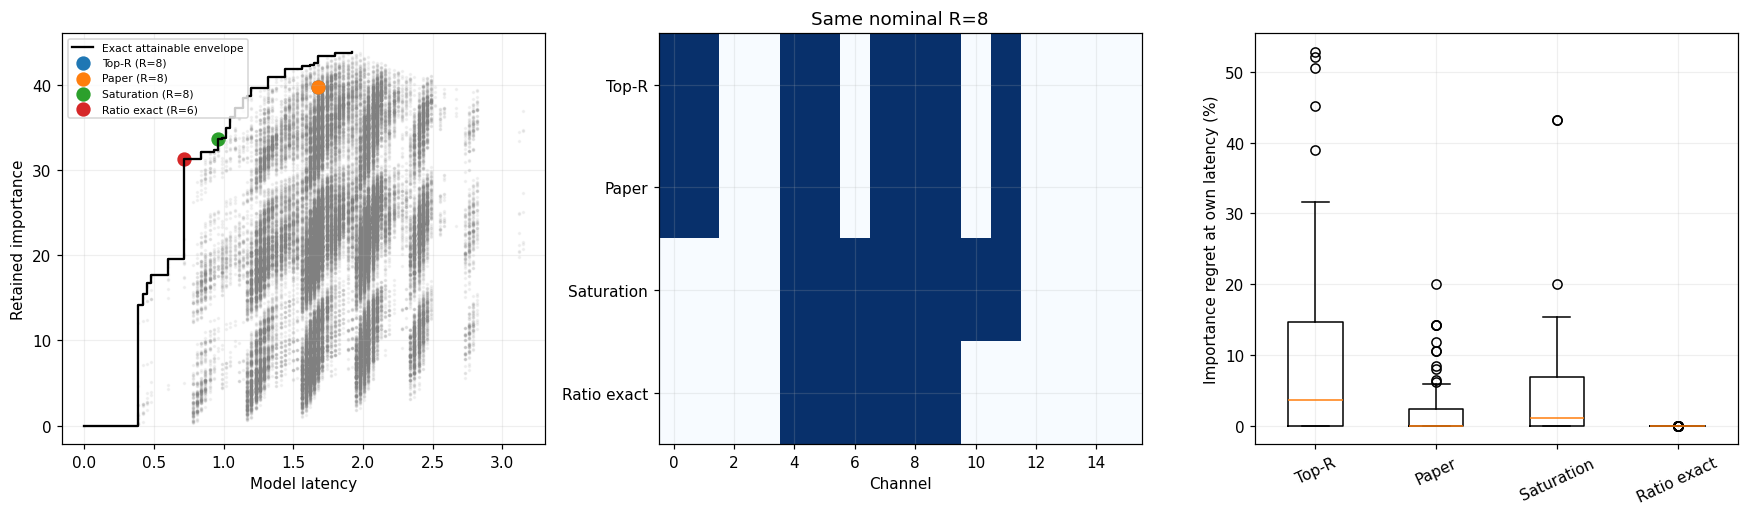

**실행에서 확인한 값**

- **cases**: 24

- **evaluated_method_points**: 288

- **masks_per_case**: 65536

- **maximum_ratio_solver_gap**: 2.220446049250313e-16

- **median_importance_gap**: {'Paper': 0.0, 'Ratio exact': 0.0, 'Saturation': 0.01068895952339853, 'Top-R': 0.03672656640806431}

- **scope**: Exact oracle for each stated synthetic additive table; no interpolation

In [3]:
v, cost, imp, delay, methods = illustration
boundary = C.frontier(imp, delay)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
axes[0].scatter(delay, imp, s=2, alpha=.08, color="gray")
axes[0].step(delay[boundary], imp[boundary], where="post", color="black", label="Exact attainable envelope")
for method, mask in methods.items():
    axes[0].scatter(C.latency(mask, cost), v[mask].sum(), s=70, label=f"{method} (R={mask.sum()})")
axes[0].set(xlabel="Model latency", ylabel="Retained importance")
axes[0].legend(fontsize=7)
axes[1].imshow(np.array(list(methods.values())), aspect="auto", cmap="Blues", interpolation="nearest")
axes[1].set(yticks=range(len(methods)), yticklabels=list(methods), xlabel="Channel", title="Same nominal R=8")
order = list(methods)
axes[2].boxplot([100 * frame.loc[frame.method == m, "importance_gap"] for m in order], tick_labels=order)
axes[2].set(ylabel="Importance regret at own latency (%)")
axes[2].tick_params(axis="x", rotation=25)
figure(RUN, "global_oracle")
finish(RUN, cases=24, evaluated_method_points=len(frame), masks_per_case=2**n,
       maximum_ratio_solver_gap=float(frame.loc[frame.method == "Ratio exact", "ratio_gap"].abs().max()),
       median_importance_gap=frame.groupby("method").importance_gap.median().to_dict(),
       scope="Exact oracle for each stated synthetic additive table; no interpolation")

## 이 실험이 닫는 논리

비율 optimum과 제약 optimum을 구분하고, “실제 optimum을 모른 채 두 heuristic만 비교하는 문제”를 작은 공간에서 제거한다. 그러나 $n=16$에서 관찰한 gap이 큰 $n$이나 hardware wall time에도 그대로 유지된다는 주장은 하지 않는다. 그 연결은 실험 05–08의 별도 측정으로 다룬다.